In [29]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
import json
from sklearn.model_selection import KFold, train_test_split
from keras.optimizers import Adam
from keras.models import Model, load_model
from keras.layers import Dense, Input, Flatten, Conv3D, BatchNormalization, Dropout, Conv2D

In [3]:
def define_baseline_mars(in_shape, n_keypoints):

    in_one = Input(shape=in_shape)
    conv_one_1 = Conv2D(
        16, kernel_size=(3, 3), activation="relu", strides=(1, 1), padding="same"
    )(in_one)
    conv_one_1 = Dropout(0.3)(conv_one_1)
    conv_one_2 = Conv2D(
        32, kernel_size=(3, 3), activation="relu", strides=(1, 1), padding="same"
    )(conv_one_1)
    conv_one_2 = Dropout(0.3)(conv_one_2)

    conv_one_2 = BatchNormalization(momentum=0.95)(conv_one_2)

    fe = Flatten()(conv_one_2)
    # dense1
    dense_layer1 = Dense(512, activation="relu")(fe)
    dense_layer1 = BatchNormalization(momentum=0.95)(dense_layer1)
    # # dropout

    # dropout
    dense_layer1 = Dropout(0.4)(dense_layer1)

    out_layer = Dense(n_keypoints, activation="linear")(dense_layer1)

    # model
    model = Model(in_one, out_layer)
    opt = Adam(learning_rate=0.001, beta_1=0.5)

    # compile the model
    model.compile(
        loss="mse",
        optimizer=opt,
        metrics=["mae", "mse", "mape", tf.keras.metrics.RootMeanSquaredError()],
    )
    return model

In [4]:
def define_temporal_MARS(in_shape, n_keypoints):
    in_one = Input(shape=in_shape)
    conv_one_1 = Conv3D(
        16, kernel_size=(3, 3, 3), activation="relu", strides=(1, 1, 1), padding="same"
    )(in_one)
    conv_one_1 = Dropout(0.3)(conv_one_1)
    conv_one_2 = Conv3D(
        32, kernel_size=(3, 3, 3), activation="relu", strides=(1, 1, 1), padding="same"
    )(conv_one_1)
    conv_one_2 = Dropout(0.3)(conv_one_2)

    conv_one_2 = BatchNormalization(momentum=0.95)(conv_one_2)

    fe = Flatten()(conv_one_2)
    # dense1
    dense_layer1 = Dense(3 * 512, activation="relu")(fe)
    dense_layer1 = BatchNormalization(momentum=0.95)(dense_layer1)
    # # dropout

    # dropout
    dense_layer1 = Dropout(0.4)(dense_layer1)

    out_layer = Dense(n_keypoints, activation="linear")(dense_layer1)

    # model
    model = Model(in_one, out_layer)
    opt = Adam(learning_rate=0.001, beta_1=0.5)

    # compile the model
    model.compile(
        loss="mse",
        optimizer=opt,
        metrics=["mae", "mse", "mape", tf.keras.metrics.RootMeanSquaredError()],
    )
    return model

In [35]:

DATASET = "dataset_main"
KINECT_PATH = os.path.join("..",DATASET, "expformatted", "kinect")
MMWAVE_PATH = os.path.join("..",DATASET, "expformatted", "mmWave")
MARS_PATH = os.path.join("..", DATASET, "expformatted", "mars")

FOLDS = 10

# EXPERIMENT = "CAAAAO"
# EXPERIMENT = "A22"
EXPERIMENT = "T1"
# EXPERIMENT = "T2"
trim_len = 2321
# trim_len = None

mmwave_data = np.load(os.path.join(MMWAVE_PATH, f"{EXPERIMENT}.npy" ))
kinect_data = np.load(os.path.join(KINECT_PATH, f"{EXPERIMENT}.npy" ))
mars_data = np.load(os.path.join(MARS_PATH, f"{EXPERIMENT}.npy"))

if trim_len:
    mmwave_data = mmwave_data[:trim_len]
    kinect_data = kinect_data[:trim_len]
    mars_data = mars_data[:trim_len]

In [36]:
print(mmwave_data.shape)
print(kinect_data.shape)
print(mars_data.shape)

(2321, 3, 8, 8, 5)
(2321, 57)
(2321, 1, 8, 8, 5)


In [38]:
batch_size = 128
epochs = 150


from datetime import datetime



def analyse_output(predicted, groundtruth):
    # Shape: (n, 57)
    # Calculate MAE, RMSE, Euclidean for ARMS
    # print(f"Predicted: {np.array(predicted).shape}")
    # print(f"Grountruth: {np.array(groundtruth).shape}")
    # pass
    pred_x = predicted[:, :19]
    pred_z = predicted[:, 19:38]
    pred_y = predicted[:, 38:]
    
    gt_x = groundtruth[:, :19]
    gt_z = groundtruth[:, 19:38]
    gt_y = groundtruth[:, 38:]

    # Compute Euclidean distance for each joint
    distances = np.sqrt((pred_x - gt_x)**2 + (pred_y - gt_y)**2 + (pred_z - gt_z)**2)  # shape (n, 19)
    # print(f"Distance: {np.array(distances).shape}, {list(distances)}")
    mae_per_joint = np.mean(distances, axis=0) 
    return  mae_per_joint


def run_model(feature, labels, train, test , model):
    history = model.fit(
        feature[train],
        labels[train],
        batch_size = batch_size,
        epochs = epochs,
        verbose=0
    )
    score_train = model.evaluate(feature[train], labels[train], verbose=0)
    print("train MAE = ", score_train[1])
    score_test = model.evaluate(feature[test], labels[test], verbose=0)
    print("test MAE = ", score_test[1])

    output_train = model.predict(feature[train], verbose=0)
    
    return score_train, score_test, output_train
        

def run_kfold_test(mmwave_data, kinect_data, output_path = "", temporal=True):
    kfold = KFold(n_splits=FOLDS, shuffle=True)
    fold_no = 1
    min_score = 100.
    # chosen_result = None
    avg_train = []
    avg_test = []
    avg_mpj = []

    for train,test in kfold.split(mmwave_data, kinect_data):
        st = datetime.now()

        print('------------------------------------------------------------------------')
        print(f'Training for fold {fold_no} ...')

        if temporal:
            keypoint_model = define_temporal_MARS(mmwave_data[train][0].shape, 57)
        else:
            keypoint_model = define_baseline_mars(mmwave_data[train][0].shape, 57)

        score_train, score_test, output_train = run_model(mmwave_data, kinect_data, train, test, keypoint_model)

        avg_train.append(score_train)
        avg_test.append(score_test)
        
        mae_per_joint = analyse_output(output_train, kinect_data[train])

        avg_mpj.append(mae_per_joint)


        if min_score > score_train[1]:
            min_score = score_test[1]
            # chosen_result = {"train":score_train, "test": score_test, "mae": mae_per_joint}
            keypoint_model.save(output_path, True)
        
        print(f"time taken: {datetime.now() - st }")
        fold_no += 1
        
    avg_train = np.array(avg_train)
    avg_test = np.array(avg_test)
    avg_mpj = np.array(avg_mpj)
    print(f"Result shape: train: {avg_train.shape}, test: {avg_test.shape}, mpj: {avg_mpj.shape}")

    # np.save("train.npy", avg_train)
    # np.save("test.npy", avg_test)
    # np.save("mpj.npy", avg_mpj)

    chosen_result = {"train": np.mean(avg_train, axis=0), "test": np.mean(avg_test, axis=0), "mae": np.mean(avg_mpj, axis=0)}

    return chosen_result
    


In [ ]:


total = mmwave_data.shape[0]
output = {}
mars_output = {}

train_idx, test_idx = train_test_split(range(total), test_size=0.2, random_state=1)
kinect_train = np.array([kinect_data[i] for i in train_idx])
kinect_test = np.array([kinect_data[i] for i in test_idx])
mmwave_train = np.array([mmwave_data[i] for i in train_idx])
mmwave_test = np.array([mmwave_data[i] for i in test_idx])
mars_train = np.array([mars_data[i] for i in train_idx])
mars_test = np.array([mars_data[i] for i in test_idx])


train_total = kinect_train.shape[0]
test_total = kinect_test.shape[0]
print(f"train size: {train_total}, test size: {test_total}")

output_path = os.path.join("..", "model", "underfitting", EXPERIMENT)
os.makedirs(output_path, exist_ok=True)
os.makedirs(os.path.join(output_path, "temporal"), exist_ok=True)
os.makedirs(os.path.join(output_path, "base"), exist_ok=True)

for i in range(1, 11):
   # break
   percent = i * 0.1
   # print(os.path.join(output_path, "temporal", f"t_{str(round(percent*100, 1))}_model.h5"))
   count = int(percent * train_total)

   selected_indices = np.random.choice(train_total, size=count, replace=False)

   mmwave_sample = mmwave_train[selected_indices]
   kinect_sample = kinect_train[selected_indices]
   mars_sample = mars_train[selected_indices]

   print(f"RUNNING {percent} TEMPORAL KFOLD {mmwave_sample.shape}")
   results_temporal = run_kfold_test(mmwave_sample, kinect_sample, os.path.join(output_path, "temporal", f"t_{str(round(percent*100, 1))}_model.h5"))

   print(f"RUNNING {percent} MARS KFOLD {mars_sample.shape}") 
   results_base = run_kfold_test(mars_sample, kinect_sample, os.path.join(output_path, "base", f"b_{str(round(percent*100, 1))}_model.h5") ,False)

   output[str(percent)] = {"temporal": results_temporal, "base": results_base}

print(f"train size: {train_total}, test size: {test_total}")





train size: 1856, test size: 465
RUNNING 0.1 TEMPORAL KFOLD (185, 3, 8, 8, 5)
------------------------------------------------------------------------
Training for fold 1 ...
train MAE =  0.19592589139938354
test MAE =  0.19446080923080444


c:\Users\amit2\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


time taken: 0:00:32.144055
------------------------------------------------------------------------
Training for fold 2 ...


KeyboardInterrupt: 

In [42]:
print(f"RUNNING MODEL TEST EVALUATIONS")

base_models = os.listdir(os.path.join(output_path, "base"))
temporal_models = os.listdir(os.path.join(output_path, "temporal"))

temporal_test_results = []
base_test_results = []

for t in temporal_models:
   model = load_model(os.path.join(output_path, "temporal", t))
   result = model.evaluate(mmwave_test, kinect_test, verbose=0)
   temporal_test_results.append(result)

for b in base_models:
   model = load_model(os.path.join(output_path, "base", b))
   result = model.evaluate(mars_test, kinect_test, verbose=0)
   base_test_results.append(result)

temporal_test_results

RUNNING MODEL TEST EVALUATIONS


[[0.08011700212955475,
  0.19892263412475586,
  0.08011700212955475,
  12068944.0,
  0.28304946422576904]]

In [ ]:
import matplotlib.pyplot as plt

def plot_results_over_steps(data):
    """
    Creates a figure with 6 subplots, each showing one of the six result values across steps.

    Parameters:
    data (list of list of float): Each inner list contains six floats, one for each result value.
    """
    # Transpose the data to separate each of the 6 result value series
    transposed = list(zip(*data))
    num_results = len(transposed)
    steps = range(len(data))

    # Create a figure with 6 subplots (vertical layout)
    fig, axs = plt.subplots(num_results, 1, figsize=(10, 12), sharex=True)

    for i in range(num_results):
        axs[i].plot(steps, transposed[i], label=f"Result {i+1}", color='tab:blue')
        axs[i].set_ylabel(f"Value {i+1}")
        axs[i].legend(loc='upper right')
        axs[i].grid(True)

    axs[-1].set_xlabel("Step")
    fig.suptitle("Results over Steps (Each Result in Separate Plot)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


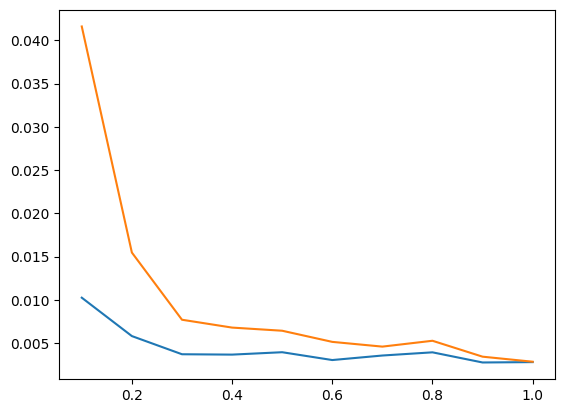

In [27]:
x_vals = []
y_vals = []
y2_vals = []
for perc in output:
    x_vals.append(float(perc))
    y_vals.append(output[perc]['base']['train'][0])
    y2_vals.append(output[perc]['temporal']['train'][0])
plt.plot(x_vals, y_vals)
plt.plot(x_vals, y2_vals)
plt.show()


# TODO for Q1
1. Update preprocessing code to create formatted data for baseline mars
2. Add code to predict the skeleton coordinate points
3. Check the euclidean error for arms
4. Plot the graphs for Euclidean error for arms, and total euclidean error, and MAE
5. Collect data for the experiments 
6. Result: minutes of activity per single dimension

Cluttered room, 1.5m sensor, 0.7m kinect, 0.15m left of sensor

Penguin Lab, 1.5m sensor, 0.8m kinect, 0.15m left of sensor

In [28]:
output

{'0.1': {'temporal': {'train': [0.041606802493333817,
    0.1376112401485443,
    0.041606802493333817,
    9252046.0,
    0.20397745072841644],
   'test': [0.2731136977672577,
    0.2159440815448761,
    0.2731136977672577,
    12932046.0,
    0.5226027965545654],
   'mae': array([0.37946687, 0.26161138, 0.22123976, 0.29627335, 0.20404785,
          0.20875528, 0.23264953, 0.22015782, 0.3897808 , 0.33465398,
          0.16728779, 0.21847248, 0.30083262, 0.239322  , 0.40232461,
          0.18105851, 0.2675826 , 0.37015023, 0.32080158])},
  'base': {'train': [0.010236000642180443,
    0.06720415502786636,
    0.010236000642180443,
    1521388.5,
    0.10117312520742416],
   'test': [0.009319246746599674,
    0.0653403252363205,
    0.009319246746599674,
    1428367.5,
    0.09653624892234802],
   'mae': array([0.11755007, 0.12400485, 0.12945222, 0.13069283, 0.1279808 ,
          0.14618715, 0.10576156, 0.08795048, 0.20815958, 0.37136705,
          0.19222648, 0.10621316, 0.08290924, 0.1

In [29]:
import json
import copy
op_json = copy.deepcopy(output)
for perc in op_json:
    for model in ['temporal', 'base']:
        for vals in ['train', 'test', 'mae']:
            op_json[perc][model][vals] = list(op_json[perc][model][vals])


with open("T2_output.json", "w") as f:
    f.write(json.dumps(op_json))

SyntaxError: invalid syntax (810060329.py, line 1)

In [33]:
def process_output(output_file):
    output = None
    with open(output_file, "r") as f:
        output = json.loads(f.read())

    total = 2321
    sample_count_values = []
    temporal_train = []
    temporal_test = []
    temporal_mae = []
    base_train = []
    base_test = []
    base_mae = []
    
    for percent in output:
        temporal_train.append(np.array(output[percent]['temporal']['train']))
        temporal_test.append(np.array(output[percent]['temporal']['test']))
        temporal_mae.append(np.array(output[percent]['temporal']['mae']))

        base_train.append(np.array(output[percent]['base']['train']))
        base_test.append(np.array(output[percent]['base']['test']))
        base_mae.append(np.array(output[percent]['base']['mae']))

        perc = float(percent)

        sample_count_values.append(perc*total)

    ttr = np.array(temporal_train)
    temporal_train_loss = ttr[:, 0]
    temporal_train_mae = ttr[:, 1]

    tte = np.array(temporal_test)
    temporal_test_loss = tte[:, 0]
    temporal_test_mae = tte[:, 1]

    btr = np.array(base_train)
    base_train_loss = btr[:, 0]
    base_train_mae = btr[:, 1]

    bte = np.array(base_test)
    base_test_loss = bte[:, 0]
    base_test_mae = bte[:, 1]

    return {"ttrl": temporal_train_loss, "ttrm": temporal_train_mae, "ttel":temporal_test_loss, "ttem":temporal_test_mae, "btrl": base_train_loss, "btrm": base_train_mae, "btel": base_test_loss, "btem": base_test_mae , "sample_count_values": sample_count_values}



t1_output = process_output("T1_output.json")
t2_output = process_output("T2_output.json")
sample_count_values = t1_output['sample_count_values']



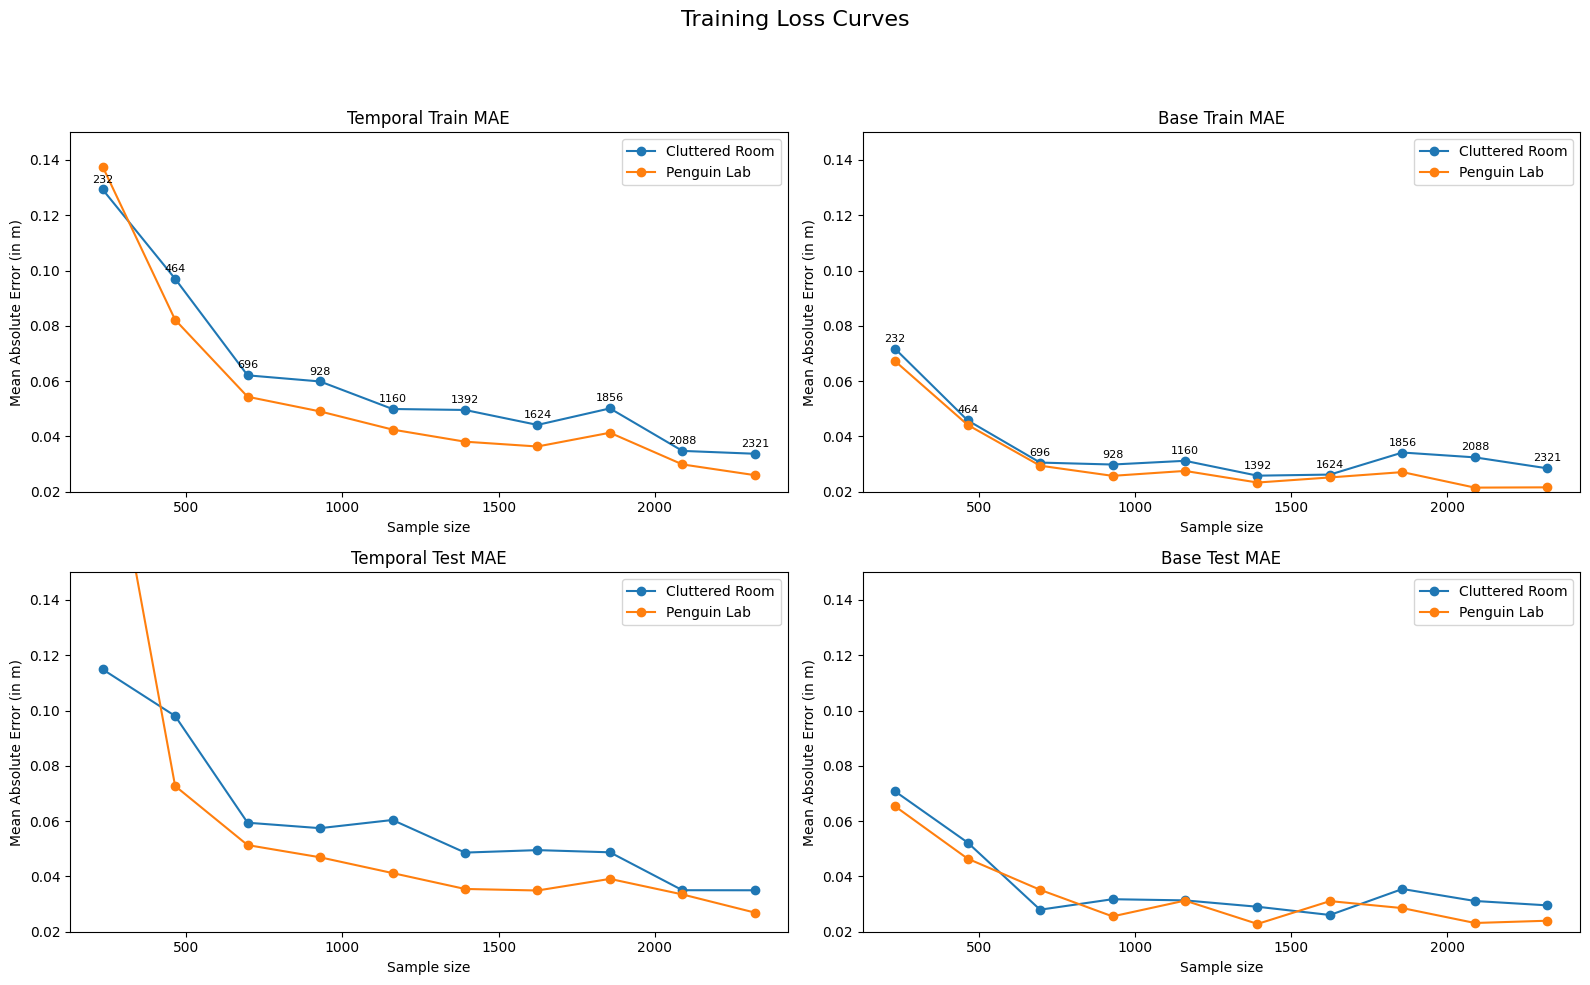

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training Loss Curves', fontsize=16)
y_lim = 0.15
# Plot on the first subplot
axes[0, 0].plot(sample_count_values, t1_output['ttrm'], marker='o', label='Cluttered Room')
axes[0, 0].plot(sample_count_values, t2_output['ttrm'], marker='o', label='Penguin Lab')
axes[0, 0].set_title('Temporal Train MAE')
axes[0, 0].set_xlabel('Sample size')
axes[0, 0].set_ylabel('Mean Absolute Error (in m)')
axes[0, 0].set_ylim(0.02, y_lim)
axes[0, 0].legend()
for x, y in zip(sample_count_values, t1_output['ttrm']):
    axes[0, 0].annotate(f'{int(x)}', (x, y), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)


axes[1, 0].plot(sample_count_values, t1_output['ttem'], marker='o', label='Cluttered Room')
axes[1, 0].plot(sample_count_values, t2_output['ttem'], marker='o', label='Penguin Lab')
axes[1, 0].set_title('Temporal Test MAE')
axes[1, 0].set_xlabel('Sample size')
axes[1, 0].set_ylabel('Mean Absolute Error (in m)')
axes[1, 0].set_ylim(0.02, y_lim)
axes[1, 0].legend()



# Plot on the second subplot
axes[0, 1].plot(sample_count_values, t1_output['btrm'], marker='o', label='Cluttered Room')
axes[0, 1].plot(sample_count_values, t2_output['btrm'], marker='o', label='Penguin Lab')
axes[0, 1].set_title('Base Train MAE')
axes[0, 1].set_xlabel('Sample size')
axes[0, 1].set_ylabel('Mean Absolute Error (in m)')
axes[0, 1].set_ylim(0.02, y_lim)
axes[0, 1].legend()
for x, y in zip(sample_count_values, t1_output['btrm']):
    axes[0, 1].annotate(f'{int(x)}', (x, y), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)

axes[1, 1].plot(sample_count_values, t1_output['btem'], marker='o', label='Cluttered Room')
axes[1, 1].plot(sample_count_values, t2_output['btem'], marker='o', label='Penguin Lab')
axes[1, 1].set_title('Base Test MAE')
axes[1, 1].set_xlabel('Sample size')
axes[1, 1].set_ylabel('Mean Absolute Error (in m)')
axes[1, 1].set_ylim(0.02, y_lim)
axes[1, 1].legend()


# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


In [ ]:
trim_len*0.6


1392.6

In [40]:
trim_len*0.4

928.4000000000001

In [44]:
(928 / trim_len ) * 300

119.94829814735027

# Cross Validation Process
1. Split the dataset into training & testing (80/20)
2. Perform K-fold cross validation on the training set
3. Average the results around the 10 folds
4. Store the best case model?
5. Perform the test set evaluation with the best case model